In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from spline_filter.tensorflow.distribution import SimpleDensityEstimator

## Train PDF

In [3]:
estimator = SimpleDensityEstimator(10, dtype=tf.float64)
# estimator = SimpleDensityEstimator([0.0, 0.25, 0.3, 0.35, 0.75, 0.8, 1.0])

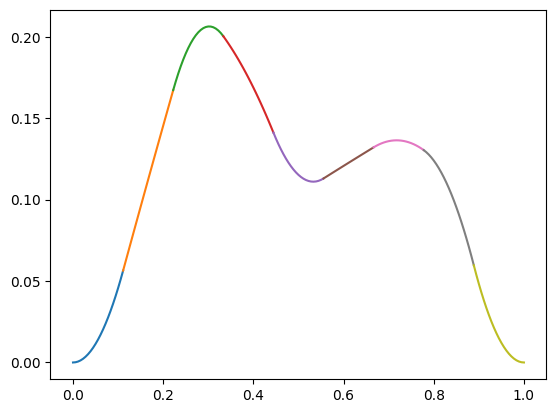

In [4]:
estimator.get_spline().plot()

In [5]:
estimator.expected_value().numpy()

0.4780874364721515

In [6]:
estimator.area().numpy()

0.1111111111111111

In [7]:
ts = tf.convert_to_tensor(np.random.normal(0.5, 0.05, size=100_000))

In [8]:
estimator.train(ts, n_epochs=20, batch_size=4096)

Epoch 1/20 50.0586454884898
Epoch 2/20 49.40464539955802
Epoch 3/20 48.768366951370446
Epoch 4/20 48.150416270597596
Epoch 5/20 47.55056439437695
Epoch 6/20 46.968381711742005
Epoch 7/20 46.40337056826506
Epoch 8/20 45.854985788711666
Epoch 9/20 45.32263955957884
Epoch 10/20 44.80570465710753
Epoch 11/20 44.303517627556054
Epoch 12/20 43.81538207812424
Epoch 13/20 43.340572096743585
Epoch 14/20 42.87833581445118
Epoch 15/20 42.42789912996843
Epoch 16/20 41.98846961947799
Epoch 17/20 41.55924065353972
Epoch 18/20 41.139395736971004
Epoch 19/20 40.72811307638547
Epoch 20/20 40.32457036493006


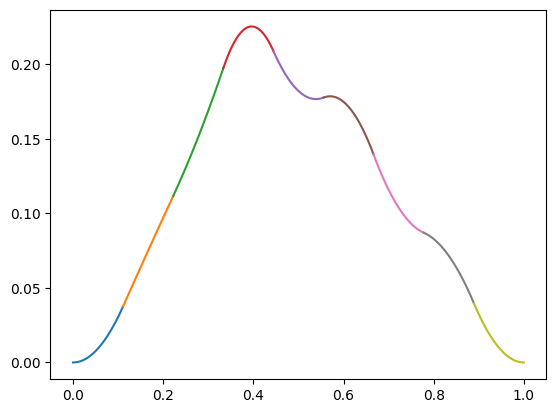

In [9]:
estimator.get_spline().plot()

In [10]:
estimator.expected_value().numpy()

0.4825932322204631

In [11]:
estimator.area().numpy()

0.1111111111111111

## Train CDF

In [12]:
estimator = SimpleDensityEstimator(7, dtype=tf.float64)
# estimator = SimpleDensityEstimator([0.0, 0.25, 0.3, 0.35, 0.75, 0.8, 1.0])

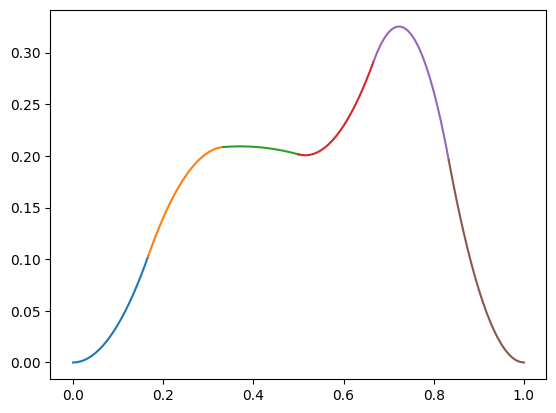

In [13]:
estimator.get_spline().plot()

In [14]:
estimator.expected_value().numpy()

0.5447807016478442

In [15]:
ts = tf.convert_to_tensor(np.random.normal(0.5, 0.05, size=10_000), dtype=tf.float64)
# t_preds = tf.convert_to_tensor(np.random.uniform(size=100_000), dtype=tf.float64)
t_preds = estimator.get_cdf_spline().sample(10_000)
over_pred_vec = tf.where(t_preds > ts, 1.0, 0.0)

In [16]:
estimator.train_cdf(t_preds, over_pred_vec, n_epochs=20, batch_size=1024)

Epoch 1/20 2.9462396599243843
Epoch 2/20 2.933834714655245
Epoch 3/20 2.921599512278798
Epoch 4/20 2.9095260437031163
Epoch 5/20 2.8976072219152487
Epoch 6/20 2.885830983225516
Epoch 7/20 2.8741824619656486
Epoch 8/20 2.862645861131053
Epoch 9/20 2.8512057041822993
Epoch 10/20 2.83984757451966
Epoch 11/20 2.828558508739288
Epoch 12/20 2.8173271713874763
Epoch 13/20 2.8061438930101934
Epoch 14/20 2.795000622162678
Epoch 15/20 2.7838908241606433
Epoch 16/20 2.772809349160418
Epoch 17/20 2.761752285706959
Epoch 18/20 2.7507168112215243
Epoch 19/20 2.7397010472425367
Epoch 20/20 2.7287039243356634


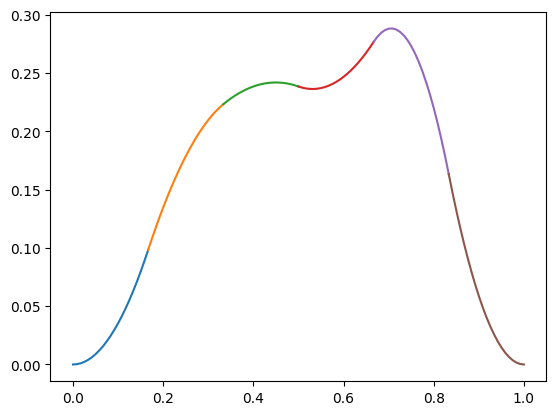

In [17]:
estimator.get_spline().plot()

In [18]:
estimator.expected_value().numpy()

0.5305444541713124

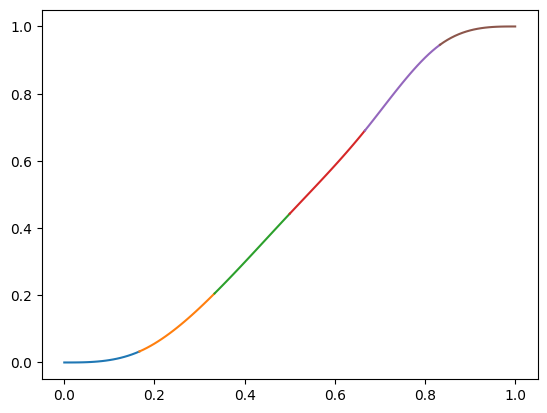

In [19]:
estimator.get_cdf_spline().plot()

## Auction scenario?

In [237]:
def run_auctions(bids, demand, floors):
    """Returns the winning bids for many auctions at once"""
    floors = floors.reshape((-1, 1))
    new_bids = np.where(
        (floors >= bids) & (floors < demand),
        # the floor plus some padding based on excess demand
        floors + (budget - floors)*0.1,
        bids)
    winning_bids = new_bids.max(axis=1)
    
    floors = floors.flatten()
    over_pred_vec = (winning_bids < floors).astype(int)
    
    return winning_bids, over_pred_vec

In [209]:
## Attempting to hide real demand theory/scenario
# desired_chance = 0.2
# low_bids = np.random.normal(0.08, 0.03, size=(n_items, n_bidders))
# winning_low_bids = np.max(low_bids, axis=1)

# plt.hist(low_bids.reshape(-1), density=True, bins=20, alpha=0.3)
# plt.hist(winning_low_bids, density=True, bins=20, alpha=0.3)
# plt.show()

In [210]:
def positive_normal(loc, sd, size=None):
    if size is None:
        value = np.random.normal(loc, sd, size=size)
        while value < 0:
            value = np.random.normal(loc, sd, size=size)
        return value
    else:
        values = np.random.normal(loc, sd, size=size)
        positive_values = values.reshape(-1).tolist()
        return np.where(values < 0.01, np.random.choice(positive_values, replace=True, size=size), values)

In [211]:
# plt.hist(np.random.gamma(1.5, scale=1/12, size=10_000) + 0.01, bins=40)

In [212]:
def get_bids_and_demand(budget, p_desired, size=None):
    p = np.random.uniform(size=size)
    demand = np.round(np.where(
        p_desired > p,
        # definitely desired case
        positive_normal(loc=budget, sd=0.05, size=size),
        # default case
        np.random.gamma(1.5, scale=1/12, size=size) * budget + 0.01 # this one has a nice shape
    ), decimals=2)
    
    bids = np.where(
        p_desired > p,
        # whatever the bidder thinks the least bourgeois bidder would pay plus some padding based on budget
        positive_normal(loc=0.20 + (budget - 0.2)*0.1, sd=0.05, size=size),
        positive_normal(loc=0.10 - budget*0.1, sd=budget*0.05, size=size)
    )
    bids = np.round(np.maximum(np.minimum(bids, demand - 0.01), 0.0), decimals=2)
    bids = bids.tolist() if size is None else bids
    demand = demand.tolist() if size is None else demand
    return bids, demand

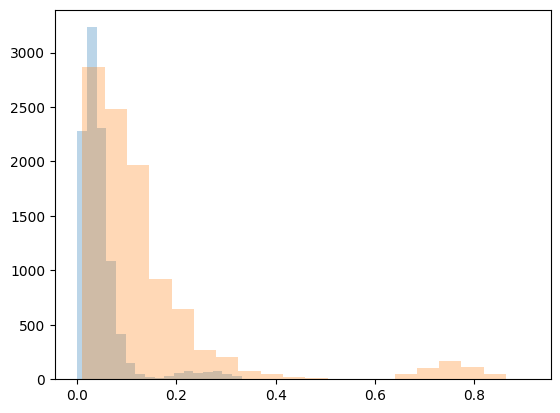

In [213]:
bids, demand = get_bids_and_demand(0.75, 0.05, size=10_000)
plt.hist(bids, bins=20, alpha=0.3)
plt.hist(demand, bins=20, alpha=0.3)
# plt.hist(demand - bids, bins=20)
plt.show()

In [214]:
bidders = [(0.2, 0.2), (0.3, 0.2), (0.4, 0.15), (0.5, 0.1), (0.75, 0.05)]
n_auctions = 100_000

bids = None
demand = None
for budget, p_desired in bidders:
    if bids is None and demand is None:
        bids, demand = get_bids_and_demand(budget, p_desired, size=n_auctions)
    else:
        new = get_bids_and_demand(budget, p_desired, size=n_auctions)
        bids = np.hstack([bids.reshape((n_auctions, -1)), new[0].reshape((n_auctions, -1))])
        demand = np.hstack([demand.reshape((n_auctions, -1)), new[1].reshape((n_auctions, -1))])

normal_winning_bids = np.max(bids, axis=1)
max_winning_bids = np.max(demand, axis=1)

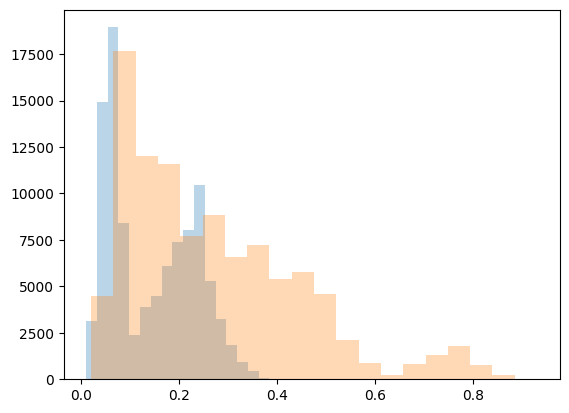

In [215]:
plt.hist(normal_winning_bids, bins=20, alpha=0.3)
plt.hist(max_winning_bids, bins=20, alpha=0.3)
plt.show()

In [216]:
normal_winning_bids.mean()

0.1428029

In [217]:
max_winning_bids.mean()

0.2690966

In [218]:
bid_estimator = SimpleDensityEstimator([0.0, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.65, 0.80, 1.00])

In [219]:
bid_estimator.train(normal_winning_bids, n_epochs=30, batch_size=1024, verbose=False)

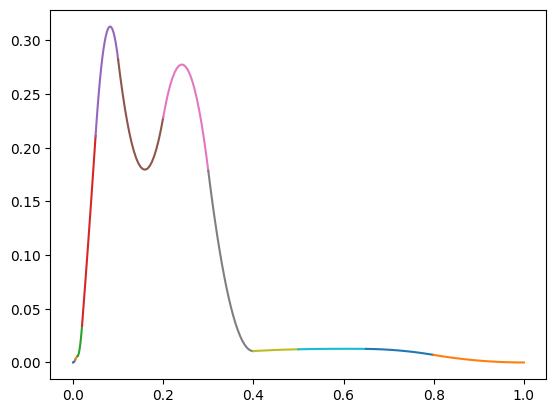

In [220]:
bid_estimator.get_spline().plot()

#### Look at it, it's beautiful

Now I want to train a distribution that looks at what happens if we interfere

In [238]:
floor_estimator = SimpleDensityEstimator([0.0, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.65, 0.80, 1.00])

In [239]:
floors = np.random.uniform(0.01, 0.99, size=(n_auctions, 1))
winning_bids, over_pred_vec = run_auctions(bids, demand, floors)

In [240]:
floor_estimator.train_cdf(
    tf.convert_to_tensor(floors, dtype=tf.float64),
    tf.convert_to_tensor(over_pred_vec, dtype=tf.float64),
    n_epochs=20,
    batch_size=1024,
    verbose=False
)

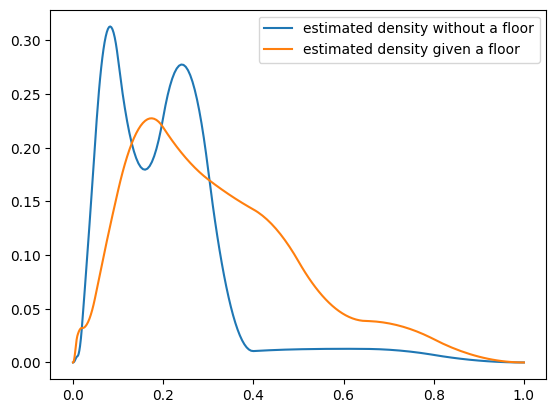

In [241]:
bid_estimator.get_spline().plot(segmented=False, label='estimated density without a floor')
floor_estimator.get_spline().plot(segmented=False, label='estimated density given a floor')
plt.legend()
plt.show()

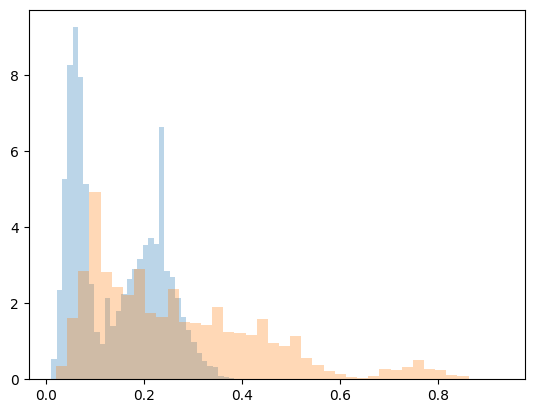

In [242]:
plt.hist(normal_winning_bids, bins=40, density=True, alpha=0.3)
plt.hist(max_winning_bids, bins=40, density=True, alpha=0.3)
plt.show()

In [234]:
bid_estimator.expected_value().numpy(), floor_estimator.expected_value().numpy()

(0.21133691888097875, 0.32115271210586793)

In [247]:
np.mean(normal_winning_bids), np.mean(winning_bids), np.mean(max_winning_bids)

(0.1428029, 0.16572823784082943, 0.2690966)

In [248]:
from tqdm import tqdm

bid_cdf = bid_estimator.get_cdf_spline()
floor_cdf = floor_estimator.get_cdf_spline()

def expected_value_w_floor(floor):
    pta = bid_cdf.get_y(floor)
    ptb = floor_cdf.get_y(floor)
    return (pta - ptb) * floor + bid_estimator.expected_value(floor).numpy()

all_floors = np.arange(0.01, 1.0, 0.01).tolist()
exp_vals = [expected_value_w_floor(x) for x in tqdm(all_floors)]
best_floor = all_floors[np.argmax(exp_vals)]
best_exp_val = max(exp_vals)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 99/99 [00:39<00:00,  2.52it/s]


In [253]:
def actual_value_w_floor(floor):
    new_bids, over_pred_vec = run_auctions(bids, demand, np.full(n_auctions, floor))
    return np.where(over_pred_vec == 1, 0, new_bids).mean()

actual_vals = [actual_value_w_floor(x) for x in all_floors]
actual_best_floor = all_floors[np.argmax(actual_vals)]
actual_best_val = max(actual_vals)

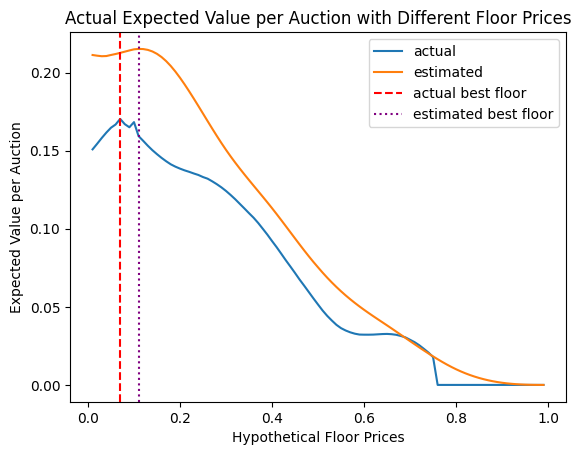

In [254]:
plt.plot(all_floors, actual_vals, label='actual')
plt.plot(all_floors, exp_vals, label='estimated')

plt.axvline(actual_best_floor, color='red', linestyle='--', label='actual best floor')
plt.axvline(best_floor, color='purple', linestyle=':', label='estimated best floor')

plt.legend()
plt.title('Actual Expected Value per Auction with Different Floor Prices')
plt.xlabel('Hypothetical Floor Prices')
plt.ylabel('Expected Value per Auction')

plt.show()

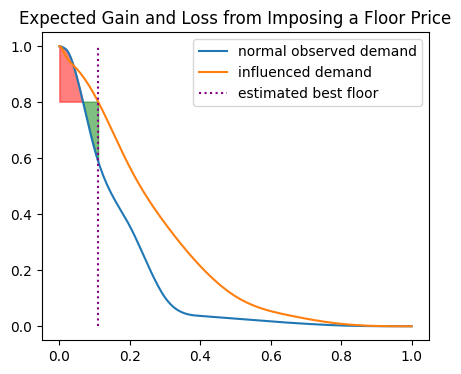

In [261]:
plt.figure(figsize=(5, 4))
bid_cdf.plot_sf(segmented=False, label='normal observed demand')
floor_cdf.plot_sf(segmented=False, label='influenced demand')

num = sum(int(best_floor >= f) for f in all_floors)
y = floor_cdf.get_y(best_floor)
curve = bid_cdf.get_curve(bid_cdf.get_curve_index(y)[0])
x = np.median(curve.solve(y))  # TODO: I don't remember how to pick the right solution out of the three possible ones; afaik, the median works
smol_num = sum(int(x >= f) for f in all_floors)

plt.plot([best_floor]*2, [0, 1], color='purple', linestyle=':', label='estimated best floor')
plt.fill_between(
    [0] + all_floors[:smol_num] + [x],
    [1] + (1 - bid_cdf.get_y_batched(np.array(all_floors[:smol_num] + [x]))).tolist(),
    [1 - y] * (smol_num + 2),
    color='red',
    alpha=0.5)
plt.fill_between(
    [x] + all_floors[smol_num:num],
    [1 - y] * (num - smol_num + 1),
    [1 - y] + (1 - bid_cdf.get_y_batched(np.array(all_floors[smol_num:num]))).tolist(),
    color='green',
    alpha=0.5)

plt.title('Expected Gain and Loss from Imposing a Floor Price')
plt.legend()
plt.show()

In [51]:
# bid_cdf = bid_estimator.get_cdf_spline()
# floor_cdf = floor_estimator.get_cdf_spline()

# hyp_floors = np.arange(0.01, 1.0, 0.01)
# e_values = [np.where(f > (normal_winning_bids + 0.20), 0.0, np.maximum(normal_winning_bids, f)).mean() for f in hyp_floors]
# # e_values2 = [floor_estimator.expected_value(f) for f in hyp_floors
# # hacky way to try to get an expected value, one which I am rethinking
# e_values2 = [floor_estimator.expected_value(f) + bid_cdf.get_y(f) * (1 - floor_cdf.get_y(f)) * f for f in hyp_floors]

# plt.plot(hyp_floors, e_values, label='actual')
# plt.plot(hyp_floors, e_values2, label='estimated')

# plt.axvline(hyp_floors[np.argmax(e_values)], color='red', linestyle='--', label='actual best')
# plt.axvline(optimal_floor, color='green', linestyle='--', label='where expected value = normal average')
# plt.axvline(optimal_floor2, color='purple', linestyle='--', label='mode of estimated dist (binary search)')
# plt.axvline(hyp_floors[np.argmax(e_values2)], color='black', linestyle='--', label='best according to estimated dists')
# plt.axvline(most_dense_t, color='hotpink', linestyle='--', label='mode of estimated dist (whole percents)')

# # plt.legend(['actual', 'estimated'])
# plt.legend()
# plt.title('Actual Expected Value per Auction with Different Floor Prices')
# plt.xlabel('Hypothetical Floor Prices')
# plt.ylabel('Expected Value per Auction')

# plt.show()

### Notes on the SimpleDensityEstimator

The contrived auction simulation is flawed. I'll need a more educated and
realistic model of how auction bidders behave before we can say that it is any
good. There is also a flaw with the `train_cdf` method. The beginning and end of
the distribution learns *too* much. The beginning and end points are *always*
learning because their values always affect either the CDF value or the SF
value. I don't know if that means that I need to weight the gradients somehow or
if that means I need to rebalance the data. But first I want to see if making
the knot values trainable fixes this problem or not.

UPDATE: Alright, I have concluded that the flexible density estimator suffers
from the same problem (beginning and ends of the distribution learning too much)
so I left the work for that at the end of the notebook and am continuing with a
new idea, Thompson Sampling.

### Thompson Sampling

We can have the bid_estimator like before, but the floors are going to be chosen randomly from the estimator first. That is, if I can prove that it is even possible to draw a sample from a spline representing a CDF. So that's got to happen first. Spoiler alert: I do figure out how to sample from a cubic B-spline.

In [266]:
cdf = bid_estimator.get_cdf_spline()

In [267]:
midpoints = (cdf.points[:-1] + cdf.points[1:]) / 2
midpoints = midpoints[2:-2]

In [268]:
# tells which curve a certain point/y-value/probability intersects with on the CDF
ind = cdf.get_curve_index(midpoints[0])[0]

In [269]:
# This is how you get a single cubic curve out of the spline
curve = cdf.get_curve(ind)
curve

Curve(a=-6780.068, b=181.531, c=-0.908, d=0.002)

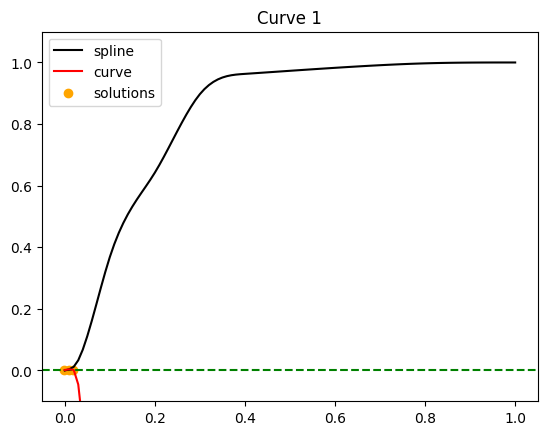

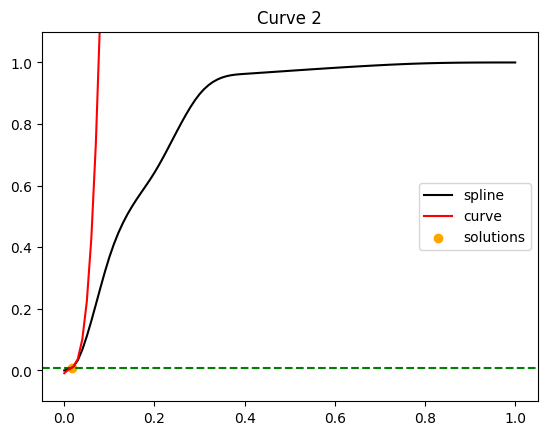

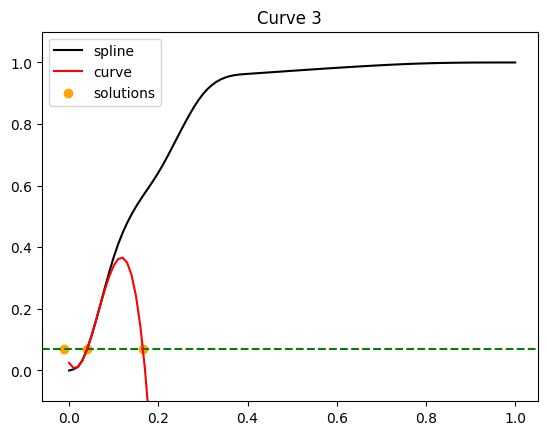

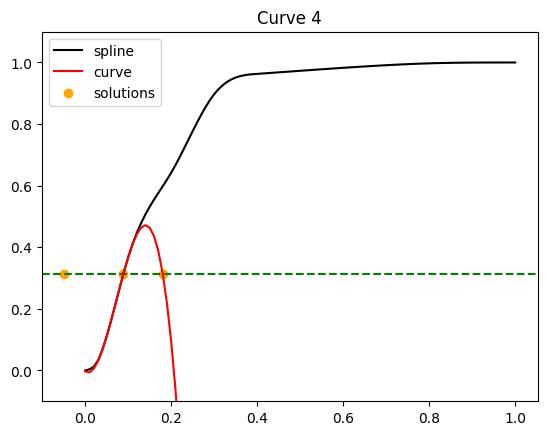

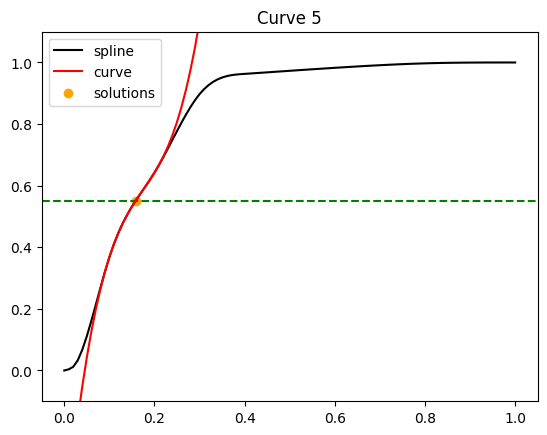

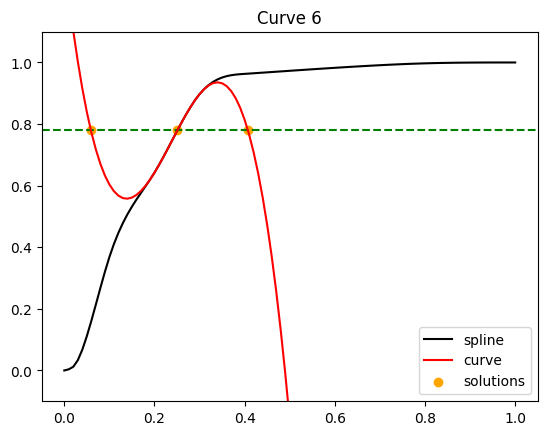

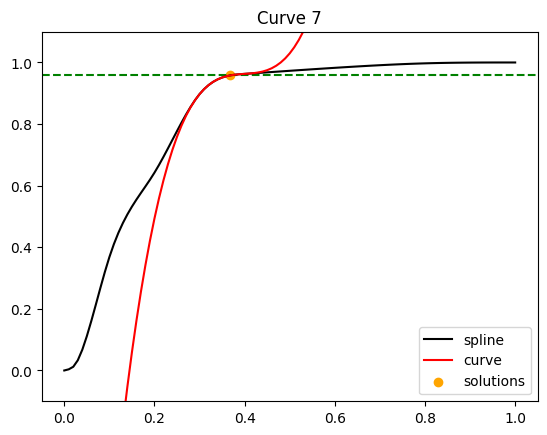

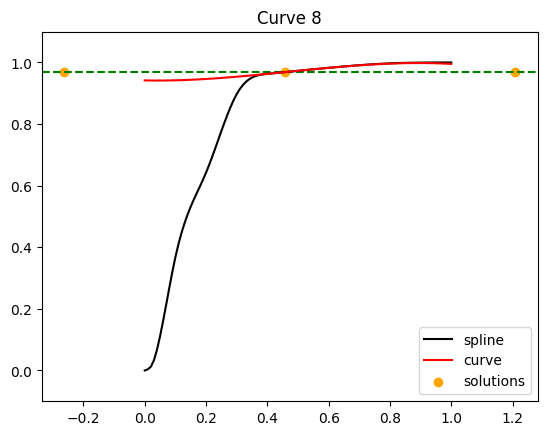

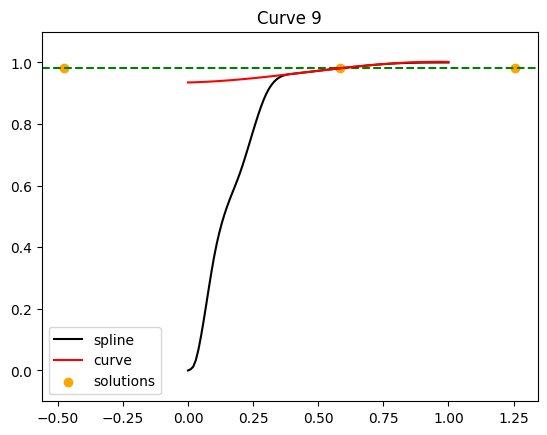

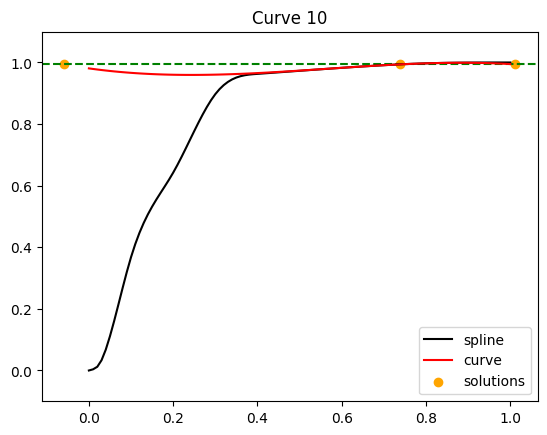

In [270]:
for midpoint in midpoints:
    curve_ind = cdf.get_curve_index(midpoint)[0]
    curve = cdf.get_curve(curve_ind)
    solutions = curve.solve(midpoint)

    ts = np.linspace(0, 1, 101)
    spline_ys = cdf.get_y_batched(ts)
    curve_ys = curve(ts)

    plt.axhline(midpoint, color='green', linestyle='--')
    plt.plot(ts, spline_ys, color='black', label='spline')
    plt.plot(ts, curve_ys, color='red', label='curve')
    plt.scatter(solutions, np.array([midpoint] * solutions.shape[0]), color='orange', label='solutions')
    plt.title(f'Curve {curve_ind}')
    plt.legend()
    plt.ylim(-0.1, 1.1)
    plt.show()
    

### Lol, we can sample now XD bahahahahahahaha what a stupid amount of work to make this functional

I'm not kidding. It took me several hours to do the math to correctly put together the coefficients for the cubic equation using the knots and points of the B-spline. And then I had to figure out the cubic equation and implement and test it.

In [271]:
# I can't believe this is actually not super slow
cdf.sample(10)

array([0.10906058, 0.15043701, 0.15653068, 0.23734963, 0.22530304,
       0.11637901, 0.11640269, 0.05621595, 0.4875265 , 0.20413307])

In [277]:
bids.shape

(100000, 5)

In [286]:
# This is the original code for training the thompson sampler
# the cell below is a cannibalization of this code; I really wanted to preserve this one
from tqdm import trange

batch_size = 1000
buffer_size = 4000
n_epochs = 5

# replay buffer-ish type thing? latest 4,000 attempts?
floors_buffer = []
over_pred_vec = []
t_winning_bids = [] # So we can compare actual revenue from this strategy against uniform sampling
all_t_over_pred = []

# brand new density estimator
thompson_sampler = SimpleDensityEstimator(12)

for i in trange(0, bids.shape[0], batch_size):
    # t_floors = this round's floors
    t_floors = thompson_sampler.get_cdf_spline().sample(batch_size)
    # t_bids = this round's bids; the presence of a floor should change the bidders' decisions
    t_bids, t_over_pred = run_auctions(bids[i:i+batch_size, :], demand[i:i+batch_size, :], t_floors)

    t_winning_bids.extend(t_bids)
    floors_buffer.extend(t_floors)
    over_pred_vec.extend(t_over_pred)
    all_t_over_pred.extend(t_over_pred)

    # let go of any old observations that are still in the buffer
    floors_buffer = floors_buffer[max(0, len(floors_buffer) - buffer_size):]
    over_pred_vec = over_pred_vec[max(0, len(over_pred_vec) - buffer_size):]
    
    thompson_sampler.train_cdf(np.array(floors_buffer), np.array(over_pred_vec), n_epochs=n_epochs, batch_size=batch_size, verbose=False)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:14<00:00,  1.35it/s]


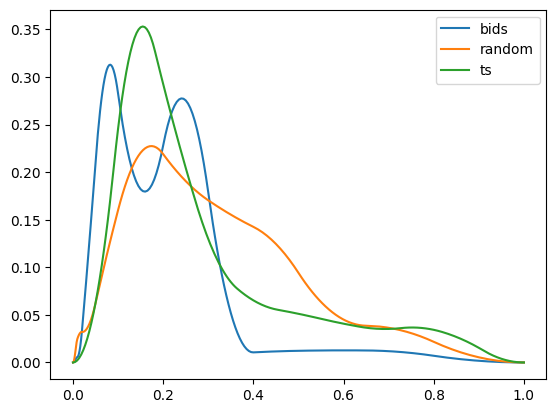

In [284]:
bid_estimator.get_spline().plot(segmented=False, label='bids')
floor_estimator.get_spline().plot(segmented=False, label='random')
thompson_sampler.get_spline().plot(segmented=False, label='ts')
plt.legend()
plt.show()

In [288]:
# (0.1428029, 0.16572823784082943, 0.2690966)
np.where(all_t_over_pred == 1, 0, t_winning_bids).mean()

0.1721462571349445

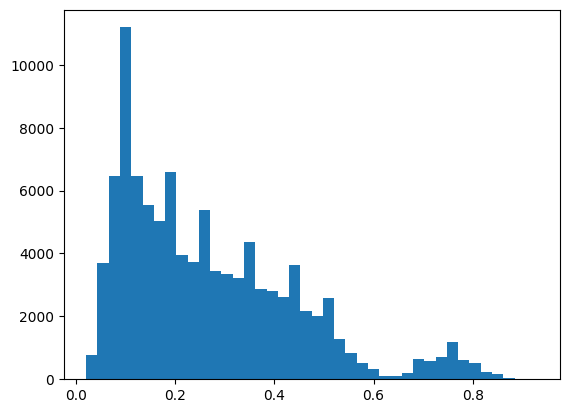

In [289]:
plt.hist(max_winning_bids, bins=40)
plt.show()

In [ ]:
# TODO: this is all outdated now
# this and the next two cells contain a monster for creating an animated gif
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from tqdm import tqdm

batch_size = 1000
buffer_size = 4000
n_epochs = 8

# replay buffer-ish type thing? 4000
bids = []
floors = []
other_new_bids = [] # So we can compare actual revenue from this strategy against uniform sampling

In [ ]:
# brand new density estimator
thompson_sampler = SimpleDensityEstimator(12)

ts = np.linspace(0, 1, 101)
fig, ax = plt.subplots()
ax.set_ylim(0, 0.25)
density_plot, = ax.plot(ts, thompson_sampler.get_spline().get_y_batched(ts))

def train_sampling_episode(i):
    global batch_size, buffer_size, n_epochs, bids, floors, other_new_bids
    i = i * batch_size
    bids.extend(normal_bids[i:i+batch_size])
    floors.extend(thompson_sampler.get_cdf_spline().sample(1000))
    bids = bids[max(0, len(bids) - buffer_size):]
    floors = floors[max(0, len(floors) - buffer_size):]
    
    cond = np.array(floors) > np.array(bids) * 1.2
    over_pred_vec = cond.astype(int).astype(np.float64)
    other_new_bids.extend(np.where(
        cond[-batch_size:],
        0.0,
        np.maximum(
            np.array(bids[-batch_size:]),
            np.array(floors[-batch_size:])
        )
    ))
    
    thompson_sampler.train_cdf(np.array(floors), over_pred_vec, n_epochs=n_epochs, batch_size=batch_size, verbose=False)

print('saving the animation')
with tqdm(total=100) as pbar:
    def animate(i):
        global ax, density_plot
        train_sampling_episode(i)
        ys = thompson_sampler.get_spline().get_y_batched(ts)
        density_plot.set_ydata(ys)
        pbar.update(1)
        return (density_plot,)
    
    ani = animation.FuncAnimation(fig, animate, repeat=True, frames=100, interval=40)
    
    # To save the animation using Pillow as a gif
    writer = animation.PillowWriter(fps=25,
                                    metadata=dict(artist='Me'),
                                    bitrate=1800)
    ani.save('thompson_sampler_training.gif', writer=writer)

In [ ]:
bids = np.array(bids)
floors = np.array(floors)
other_new_bids = np.array(other_new_bids)

In [ ]:
floor_estimator.get_spline().plot(segmented=False, label='floor estimator')
thompson_sampler.get_spline().plot(segmented=False, label='thompson sampler')
plt.title('floor estimator vs thompson sampler')
plt.legend()
plt.show()

In [ ]:
plt.hist(new_bids[np.where(new_bids != 0)], bins=40)
plt.title('new_bids: (' + str((new_bids == 0).sum()) + ' == 0)')
plt.show()

In [ ]:
plt.hist(np.array(other_new_bids)[np.where(other_new_bids != 0)], bins=40)
plt.title('other_new_bids: (' + str((np.array(other_new_bids) == 0).sum()) + ' == 0)')
plt.show()

In [ ]:
max_bids = np.minimum(1.0, normal_bids * 1.2)

In [ ]:
plt.hist(max_bids, bins=40)
plt.show()

In [ ]:
plt.hist(thompson_sampler.get_cdf_spline().sample(100_000), bins=40)
plt.title('bids sampled from thompson sampler')
plt.show()

In [ ]:
np.mean(normal_bids), np.mean(new_bids), np.mean(other_new_bids), np.mean(max_bids)

That's fascinating. The Thompson sampler was better at staying under the threshold and it generated more revenue that the uniformly sampled floors. It also seems to have a smoother distribution. There's less of a peak at the end on the right side. Thinking about it now, it makes a ton of sense for the altered distribution to have a peak near the end because of all the max bids that are greater than the domain of the space (>1.0, this flaw in the auction bids has since been fixed). Also fascinating that learning via Thompson sampling leads to such different results.

Oh yeah, let's just double check that the sampling method is working.

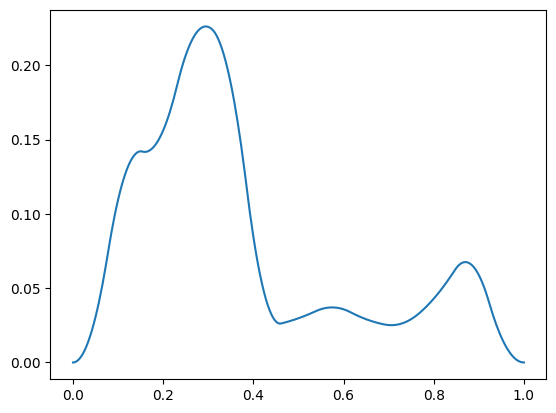

In [107]:
thompson_sampler.get_spline().plot(segmented=False)

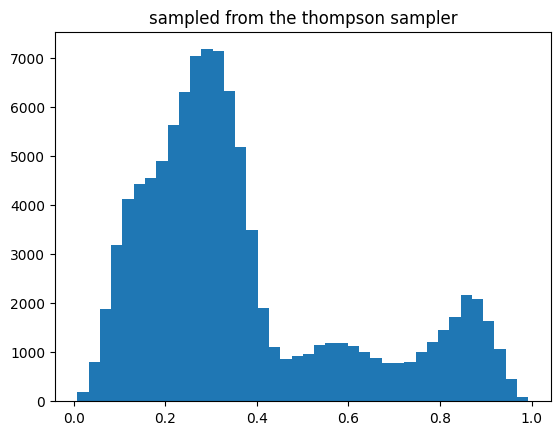

In [108]:
plt.hist(thompson_sampler.get_cdf_spline().sample(100_000), bins=40)
plt.title('sampled from the thompson sampler')
plt.show()

In [109]:
# I'd say that fits the distribution estimated by the thompson sampler

In [110]:
%%time
thompson_sampler.get_cdf_spline().sample(100_000)

CPU times: total: 4.38 s
Wall time: 4.38 s


array([0.23261898, 0.1401326 , 0.04251989, ..., 0.35619567, 0.3078108 ,
       0.10949031])

In [114]:
%%time
thompson_sampler.get_cdf_spline().sample(1)

CPU times: total: 0 ns
Wall time: 0 ns


0.2737898917967474

## FlexibleDensityEstimator

In [115]:
from spline_filter.tensorflow.distribution import FlexibleDensityEstimator

## Train PDF

In [116]:
estimator = FlexibleDensityEstimator(3)

In [117]:
spline = estimator.get_spline()

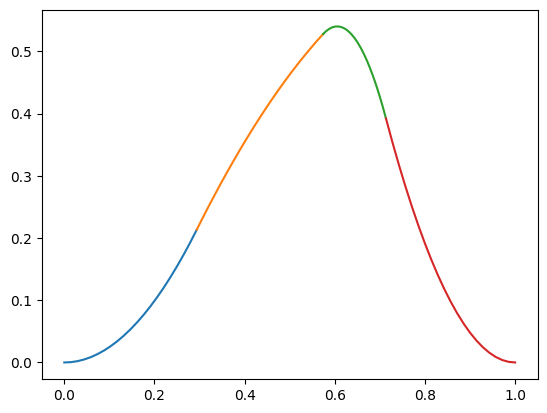

In [118]:
spline.plot()

In [119]:
estimator.area()

0.27408227916284966

In [120]:
estimator.expected_value()

0.5343790260115159

In [121]:
import tensorflow as tf
import numpy as np

In [122]:
ts = tf.convert_to_tensor(np.random.normal(0.5, 0.05, size=100_000), dtype=tf.float64)

In [123]:
estimator.train(ts, n_epochs=20, batch_size=4096)

Epoch 1/20 18.55515834899972
Epoch 2/20 18.072135755811093
Epoch 3/20 17.705224161446157
Epoch 4/20 17.44225570464915
Epoch 5/20 17.253125585277683
Epoch 6/20 17.09854882200074
Epoch 7/20 16.938090198320836
Epoch 8/20 16.737805492392773
Epoch 9/20 16.475079980728566
Epoch 10/20 16.140306796806108
Epoch 11/20 15.736900063635241
Epoch 12/20 15.279356072985964
Epoch 13/20 14.788795419772876
Epoch 14/20 14.287248615191949
Epoch 15/20 13.793294486954833
Epoch 16/20 13.320192893421082
Epoch 17/20 12.875649067600769
Epoch 18/20 12.462756389265506
Epoch 19/20 12.081199267062448
Epoch 20/20 11.728705345988233


In [124]:
spline = estimator.get_spline()

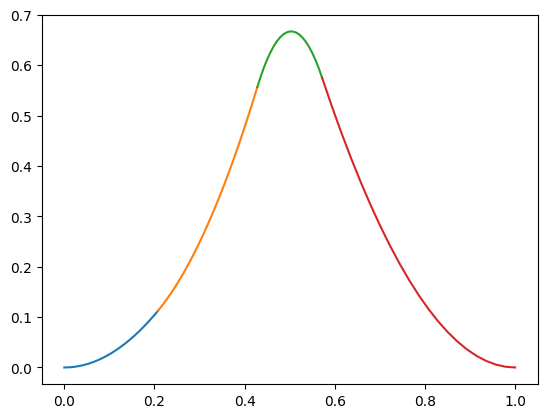

In [125]:
spline.plot()

In [126]:
estimator.expected_value()

0.4985860736695392

## Train CDF

In [127]:
estimator = FlexibleDensityEstimator(7)

In [128]:
spline = estimator.get_spline()

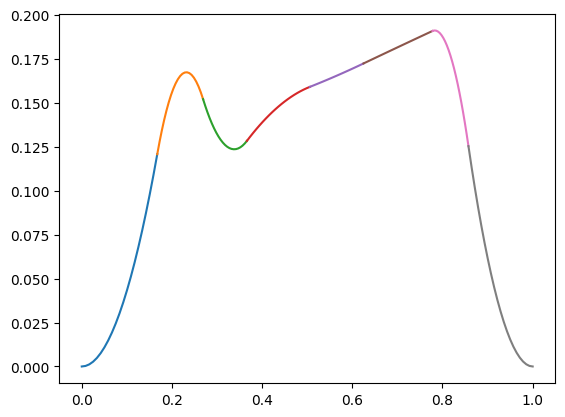

In [129]:
spline.plot()

In [130]:
estimator.expected_value()

0.5211259193593923

In [131]:
ts = tf.convert_to_tensor(np.random.normal(0.5, 0.05, size=100_000), dtype=tf.float64)
t_preds = tf.convert_to_tensor(np.random.uniform(size=100_000), dtype=tf.float64)
over_pred_vec = tf.where(t_preds > ts, 1.0, 0.0)

In [132]:
estimator.train_cdf(t_preds, over_pred_vec, n_epochs=20, batch_size=1024)

Epoch 1/20 23.16508249759548
Epoch 2/20 20.969781479406546
Epoch 3/20 18.967779223589634
Epoch 4/20 17.19181740642124
Epoch 5/20 15.656265173948716
Epoch 6/20 14.35798666653584
Epoch 7/20 13.281623621055203
Epoch 8/20 12.404740108714714
Epoch 9/20 11.701502176386347
Epoch 10/20 11.145140862533713
Epoch 11/20 10.709805990072276
Epoch 12/20 10.371928737392444
Epoch 13/20 10.110991580764464
Epoch 14/20 9.90981334017528
Epoch 15/20 9.754413268813106
Epoch 16/20 9.63366713104499
Epoch 17/20 9.538907153247738
Epoch 18/20 9.4634989265161
Epoch 19/20 9.402437072570779
Epoch 20/20 9.35199716561792


In [133]:
spline = estimator.get_spline()

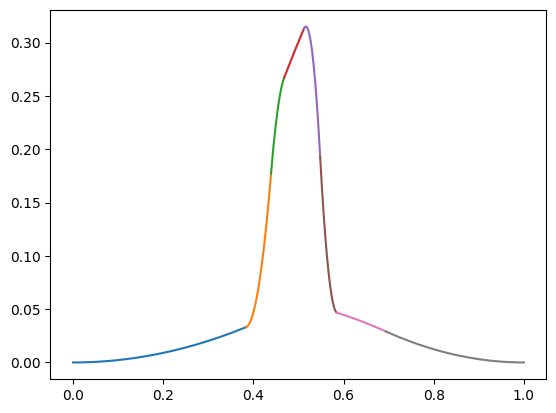

In [134]:
spline.plot()

In [135]:
estimator.expected_value()

0.43000796728398866

### Try the auction simulation again

In [136]:
n_bidders = 5
n_items = 100_000
values = np.random.uniform(size=n_items)
get_smart_p = np.random.uniform(size=(n_items, n_bidders))
perceptions = np.sqrt(np.random.uniform(size=(n_items, n_bidders)) * values.reshape((-1, 1)))
perceptions = np.where(get_smart_p > 0.9, perceptions, perceptions / 3)

In [137]:
normal_bids = perceptions.max(axis=1)

In [138]:
normal_bids.shape

(100000,)

In [139]:
(get_smart_p.max(axis=1) > 0.9).sum()

40675

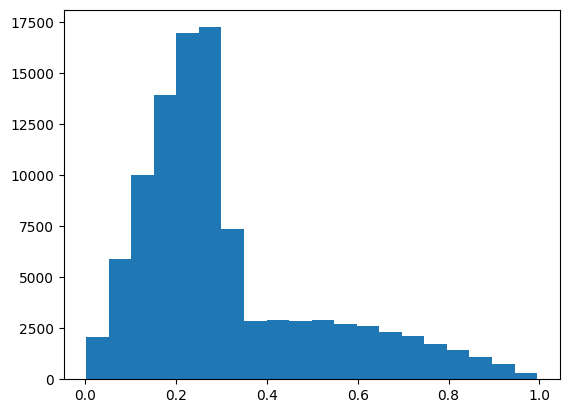

In [140]:
import matplotlib.pyplot as plt
plt.hist(normal_bids, bins=20)
plt.show()

In [141]:
bid_estimator = FlexibleDensityEstimator(7)

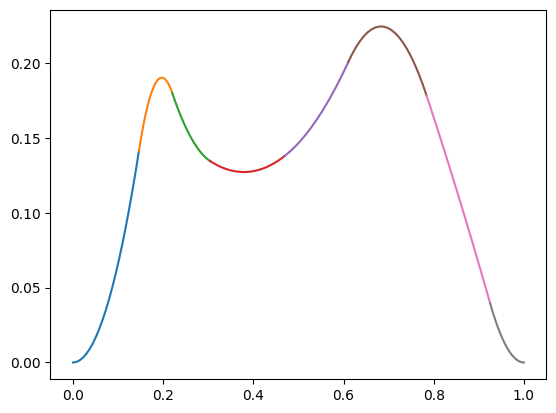

In [142]:
bid_estimator.get_spline().plot()

In [143]:
bid_estimator.train(tf.convert_to_tensor(normal_bids, dtype=tf.float64), n_epochs=20, batch_size=1024)

Epoch 1/20 193.56765756403533
Epoch 2/20 186.44500191010337
Epoch 3/20 180.22568261854732
Epoch 4/20 174.1655938885787
Epoch 5/20 168.29944702965227
Epoch 6/20 162.7549473548275
Epoch 7/20 157.45673480804442
Epoch 8/20 152.29971410597446
Epoch 9/20 147.21747893652622
Epoch 10/20 142.13701936610425
Epoch 11/20 136.90127036397746
Epoch 12/20 131.30903652484992
Epoch 13/20 125.30674267832427
Epoch 14/20 119.11964874383764
Epoch 15/20 113.14622414563965
Epoch 16/20 107.72421777979449
Epoch 17/20 103.0114681573532
Epoch 18/20 99.00794259548742
Epoch 19/20 95.63365008381707
Epoch 20/20 92.78581865525817


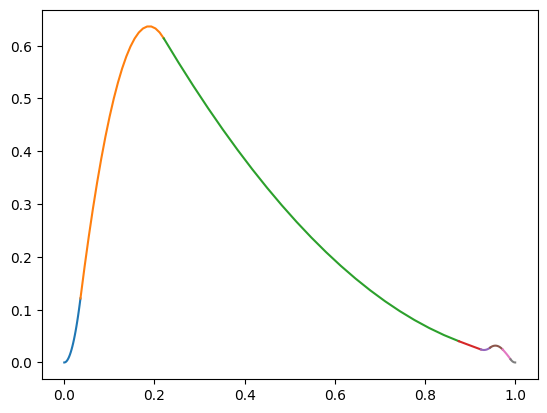

In [144]:
bid_estimator.get_spline().plot()

In [145]:
bid_estimator.expected_value()

0.4267868717355458

In [146]:
normal_bids.mean()

0.3103855080985147

#### Look at it, it's beautiful

Now I want to train a distribution that looks at what happens if we interfere

In [147]:
floor_estimator = FlexibleDensityEstimator(12)

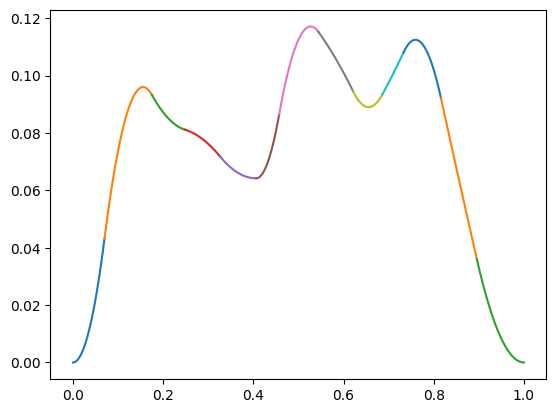

In [148]:
floor_estimator.get_spline().plot()

In [149]:
floors = np.random.uniform(0.01, 0.99, size=100_000)
new_bids = np.where(floors > normal_bids, 0.0, np.maximum(floors, normal_bids))
over_pred_vec = (new_bids == 0).astype(int)

In [150]:
floor_estimator.train_cdf(
    tf.convert_to_tensor(floors, dtype=tf.float64),
    tf.convert_to_tensor(over_pred_vec, dtype=tf.float64),
    n_epochs=20,
    batch_size=1024)

Epoch 1/20 45.19511808007781
Epoch 2/20 40.52674671939368
Epoch 3/20 37.53262387452045
Epoch 4/20 35.715807464380624
Epoch 5/20 34.679445871454924
Epoch 6/20 34.12325518769591
Epoch 7/20 33.83614853326343
Epoch 8/20 33.686519849580066
Epoch 9/20 33.60231673975957
Epoch 10/20 33.54860973978413
Epoch 11/20 33.509986260646755
Epoch 12/20 33.47992296599938
Epoch 13/20 33.45556274598801
Epoch 14/20 33.43550516189272
Epoch 15/20 33.418939958517015
Epoch 16/20 33.40530566097582
Epoch 17/20 33.39415131099204
Epoch 18/20 33.385082783713145
Epoch 19/20 33.37774579723606
Epoch 20/20 33.37182348187274


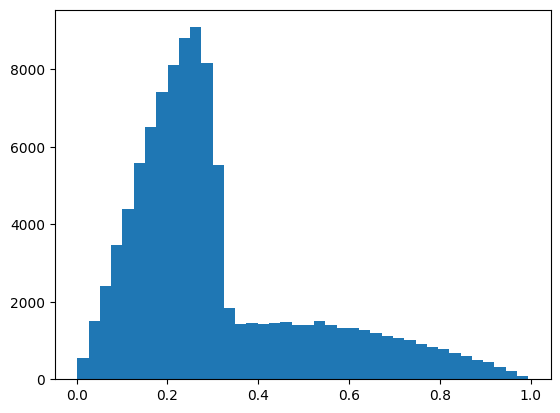

In [151]:
plt.hist(normal_bids, bins=40)
plt.show()

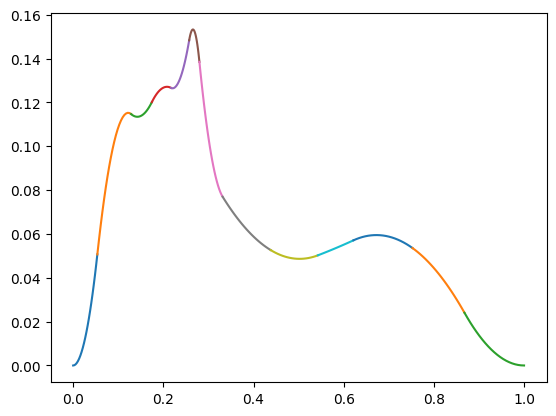

In [152]:
floor_estimator.get_spline().plot()

### I have no idea why training on the CDF is working so much better than training on the PDF

In [153]:
floor_estimator = FlexibleDensityEstimator(12)

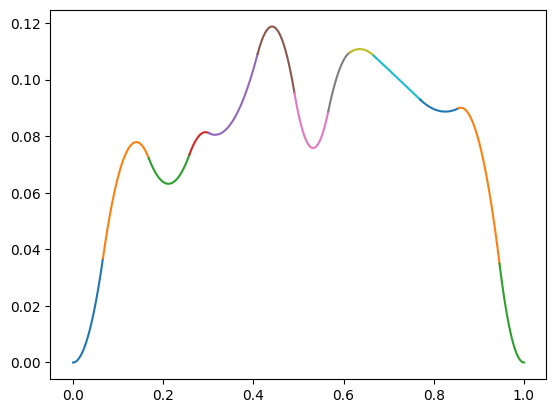

In [154]:
floor_estimator.get_spline().plot()

In [155]:
floors = np.random.uniform(0.01, 0.99, size=100_000)
new_bids = np.where(floors > normal_bids * 1.5, 0.0, np.maximum(floors, normal_bids))
over_pred_vec = (new_bids == 0).astype(int)

In [156]:
floor_estimator.train_cdf(
    tf.convert_to_tensor(floors, dtype=tf.float64),
    tf.convert_to_tensor(over_pred_vec, dtype=tf.float64),
    n_epochs=20,
    batch_size=1024)

Epoch 1/20 49.119757668167146
Epoch 2/20 47.625426240016075
Epoch 3/20 46.85761243628046
Epoch 4/20 46.37782036068394
Epoch 5/20 46.026031464110396
Epoch 6/20 45.74980986162139
Epoch 7/20 45.52782406375197
Epoch 8/20 45.347520306233186
Epoch 9/20 45.19960235787675
Epoch 10/20 45.076726568474115
Epoch 11/20 44.97319536177626
Epoch 12/20 44.884671562292134
Epoch 13/20 44.80798856053685
Epoch 14/20 44.74088025514896
Epoch 15/20 44.68171358429098
Epoch 16/20 44.62930295906006
Epoch 17/20 44.58276033648042
Epoch 18/20 44.54138675520169
Epoch 19/20 44.504599979375335
Epoch 20/20 44.47189794510982


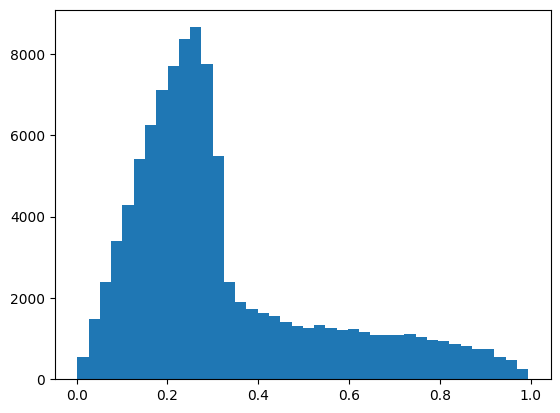

In [157]:
plt.hist(np.where(new_bids == 0, normal_bids, new_bids), bins=40)
plt.show()

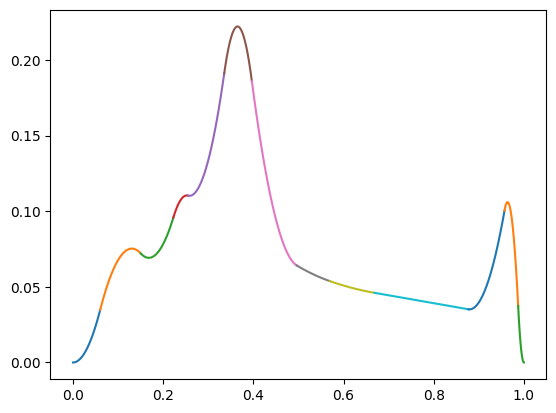

In [158]:
floor_estimator.get_spline().plot()

### There are some artifacts in the flexible estimator that I'm not quite able to understand

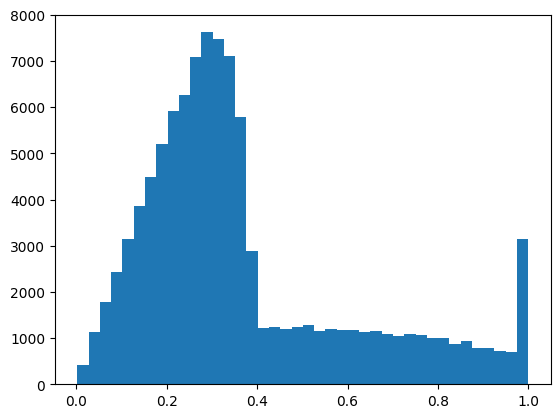

In [161]:
plt.hist(max_bids, bins=40);